In [ ]:
from sklearn.mixture import GaussianMixture
# from sklearn.datasets import load_iris
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score, silhouette_score

from sklearn.decomposition import PCA

import numpy as np
import matplotlib.pyplot as plt

from models.gmm import GaussianMixtureModel
from models.gmm import GMMMissing

from utils.data_loader import load_gaussian, load_iris, load_penguins
from utils.imputer import MeanTabularImputer, KNNTabularImputer, MedianTabularImputer

from utils import TabularMissingness

import seaborn as sns
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
X, y = load_iris(return_numpy=True)

missingness = TabularMissingness()

In [3]:
def plot(X, missing, imputed, prediction, y):
    is_imputed = np.isnan(missing).any(axis=1)

    fig, ax = plt.subplots(2, 2, figsize=(9, 7))

    ax[0][0].scatter(X[:, 0], X[:, 1], c=y, s=25, alpha=0.7, cmap='viridis')
    ax[0][0].set_title('Original Data (Ground Truth)')

    ax[0][1].scatter(missing[:, 0], missing[:, 1], c=y, s=25, alpha=0.7, cmap='viridis')
    ax[0][1].set_title('Data with Missing Values (NaNs)')

    ax[1][0].scatter(imputed[:, 0], imputed[:, 1], c=is_imputed, s=25, cmap='autumn', alpha=0.6)
    ax[1][0].set_title('Imputed Data (Red/Yellow = Filled)')

    ax[1][1].scatter(imputed[:, 0], imputed[:, 1], c=prediction, s=25, alpha=0.7, cmap='tab10')
    ax[1][1].set_title('GMM Cluster Predictions')

    for row in ax:
        for a in row:
            a.set_xlabel('Feature 0')
            a.set_ylabel('Feature 1')

    fig.tight_layout()
    plt.show()

Stratified MAR Evaluation (TabularMissingness Class):
ARI: 0.7275
NMI: 0.7870


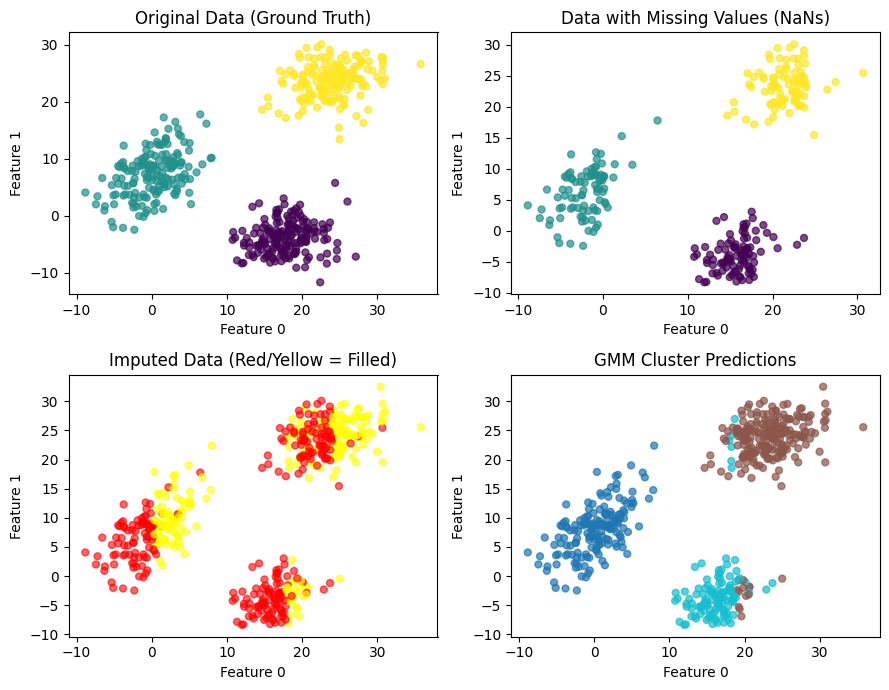

In [4]:
n_classes = 3
X, y = load_gaussian(n_samples=500, n_features=2, centers=n_classes, random_state=42)

missing_data = missingness.apply_stratified(
    X, y,
    method="mar",
    frac=0.90,
    dep_col=0,
    miss_col=1,
    random_state=42
)

gmm = GMMMissing(n_components=n_classes, random_state=42)
gmm.fit(missing_data)

prediction = gmm.predict(missing_data)
imputed_data = gmm.impute(missing_data, stochastic=True)

y_missing = np.isnan(missing_data).any(axis=1).astype(int)

ari = adjusted_rand_score(y, prediction)
nmi = normalized_mutual_info_score(y, prediction)

print(f"Stratified MAR Evaluation (TabularMissingness Class):")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")

# 4. Run your plot
plot(X, missing_data, imputed_data, prediction, y)

Stratified MAR Evaluation:
ARI: 0.9235
NMI: 0.8798


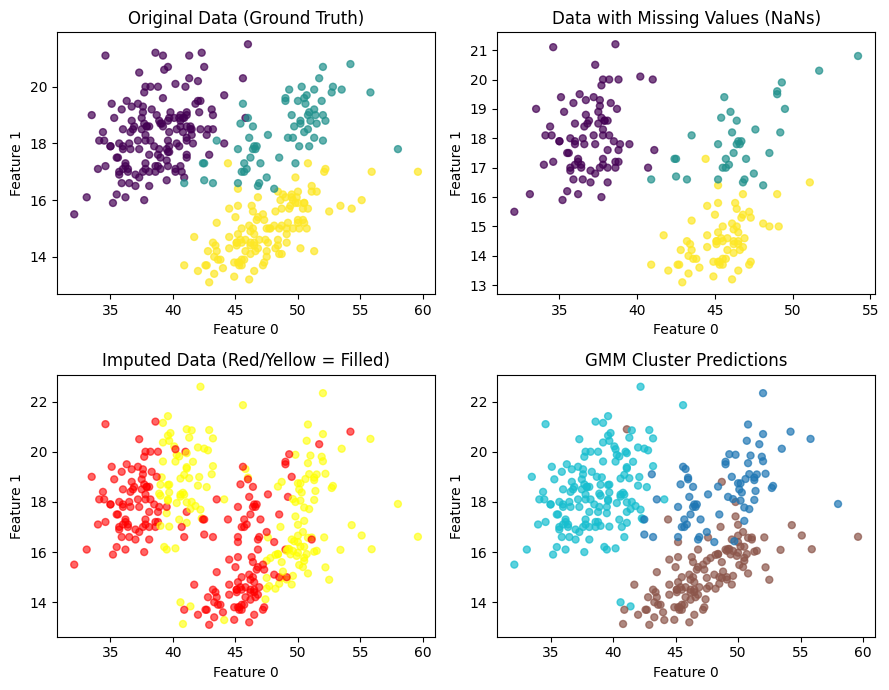

In [44]:
n_classes = 3
X, y = load_penguins(return_numpy=True)
classes, y_num = np.unique(y, return_inverse=True)

missing_data = missingness.apply_stratified(
    X, y,
    method="mar",
    frac=0.90,
    dep_col=0,
    miss_col=1,
    random_state=42
)

gmm = GMMMissing(n_components=n_classes)
gmm.fit(missing_data)

prediction = gmm.predict(missing_data)
imputed_data = gmm.impute(missing_data, stochastic=True)

y_missing = np.isnan(missing_data).any(axis=1).astype(int)

ari = adjusted_rand_score(y, prediction)
nmi = normalized_mutual_info_score(y, prediction)

print(f"Stratified MAR Evaluation:")
print(f"ARI: {ari:.4f}")
print(f"NMI: {nmi:.4f}")

plot(X, missing_data, imputed_data, prediction, y_num)

In [42]:
X, y = load_gaussian(centers=1)

missing_data = missingness.apply_stratified(
    X, y,
    method="mcar",
    frac=0.50,
    random_state=42
)

imputed_mean = MeanTabularImputer().impute(missing_data)
imputed_knn = KNNTabularImputer(k=2).impute(missing_data)


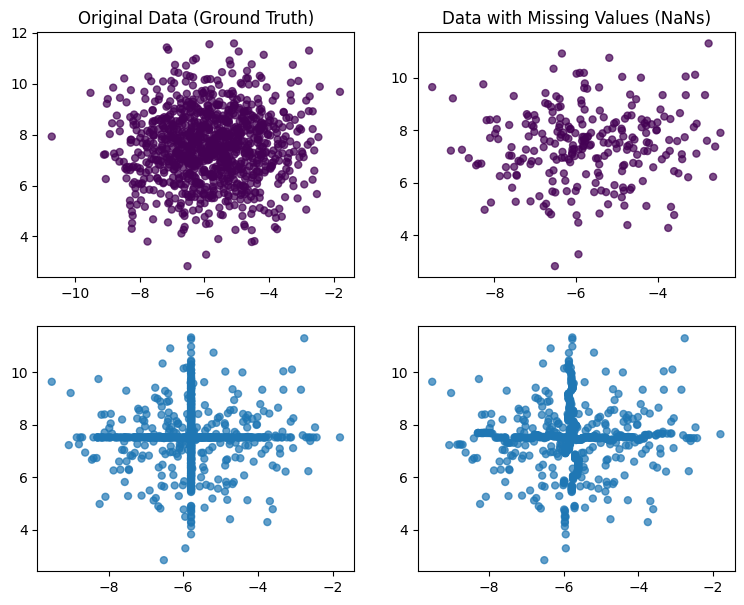

In [43]:
fig, ax = plt.subplots(2, 2, figsize=(9, 7))

ax[0][0].scatter(X[:, 0], X[:, 1], c=y, s=25, alpha=0.7, cmap='viridis')
ax[0][0].set_title('Original Data (Ground Truth)')
ax[0][1].scatter(missing_data[:, 0], missing_data[:, 1], c=y, s=25, alpha=0.7, cmap='viridis')
ax[0][1].set_title('Data with Missing Values (NaNs)')

ax[1][0].scatter(imputed_mean[:, 0], imputed_mean[:, 1], c=y, s=25, alpha=0.7, cmap='tab10')
ax[1][1].scatter(imputed_knn[:, 0], imputed_knn[:, 1], c=y, s=25, alpha=0.7, cmap='tab10')
plt.show()